# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Shakir-j/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Action playbook

The queue is a review-priority list, not an automatic publishing or editing system.

The primary action pattern carried forward from the validated Week-4 baseline is:

**Meaningful visibility + top-20 average position + CTR below 3% → REVIEW_CTR**

This pattern is useful because the page already has search visibility but may have a click-through weakness. The reason code is `visible_low_ctr`.

I also use a second review archetype for aging content. The research paper reports that content health tends to weaken as pages age and that freshness is associated with stronger observed growth patterns. This supports reviewing older pages for staleness, but it does not prove that refreshing a page will cause improvement.

The queue therefore ranks pages for human review rather than automatically prescribing an edit.

### Reason codes

- `visible_low_ctr` — meaningful visibility, top-20 position, and CTR below 3%; review the search result and query intent before changing the page.
- `aging_refresh_review` — older content with meaningful visibility; check whether facts, examples, structure, or coverage are stale before deciding whether to refresh.
- `no_action` — does not meet the review conditions above.

### Archetype → action mapping

| Archetype | Reason code | Suggested action |
|---|---|---|
| Visible but low CTR | `visible_low_ctr` | Review title, snippet intent, SERP context, and query alignment |
| Aging page with useful visibility | `aging_refresh_review` | Human review for stale facts, missing coverage, and outdated examples |
| No strong review signal | `no_action` | Do not prioritize from this playbook alone |

The action labels describe what should be reviewed first. They do not claim that completing the action will cause a performance increase.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# SECTION 1 — RANKED ACTIONS + REASON CODES
# ============================================================

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata


# ------------------------------------------------------------
# 1. Connect to the FlyRank warehouse
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise RuntimeError(
        "HF_TOKEN not found. Check Colab Secrets and make sure "
        "the secret is named exactly HF_TOKEN."
    )

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"


# ------------------------------------------------------------
# 2. Build the February action-review frame
# ------------------------------------------------------------

action_frame = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(COALESCE(gsc_impressions, 0))
        AS gsc_impressions,

    SUM(COALESCE(gsc_clicks, 0))
        AS gsc_clicks,

    AVG(gsc_avg_position)
        AS gsc_avg_position,

    SUM(COALESCE(ga4_sessions, 0))
        AS ga4_sessions,

    SUM(COALESCE(scroll_events, 0))
        AS scroll_events

FROM {FEB}

GROUP BY
    client_hash_id,
    content_hash_id
""").df()


# ------------------------------------------------------------
# 3. Calculate CTR
# ------------------------------------------------------------

action_frame["ctr_pct"] = (
    100.0
    * action_frame["gsc_clicks"]
    / action_frame["gsc_impressions"].replace(0, np.nan)
)


# ------------------------------------------------------------
# 4. Define review archetypes
# ------------------------------------------------------------

visible_low_ctr = (
    (action_frame["gsc_impressions"] >= 100)
    & (action_frame["gsc_avg_position"] <= 20)
    & (action_frame["ctr_pct"] < 3)
)

action_frame["reason_code"] = np.select(
    [
        visible_low_ctr
    ],
    [
        "visible_low_ctr"
    ],
    default="no_action"
)

action_frame["action_label"] = np.select(
    [
        visible_low_ctr
    ],
    [
        "REVIEW_CTR"
    ],
    default="NO_ACTION"
)


# ------------------------------------------------------------
# 5. Build a transparent review-priority score
# ------------------------------------------------------------

# Higher visibility and stronger position increase review priority.
# Lower CTR increases the CTR-review signal.
#
# This is a prioritization score, NOT a predicted business impact.

action_frame["visibility_score"] = np.log1p(
    action_frame["gsc_impressions"]
)

action_frame["position_score"] = (
    21 - action_frame["gsc_avg_position"]
).clip(lower=0)

action_frame["ctr_gap_score"] = (
    3 - action_frame["ctr_pct"]
).clip(lower=0)

action_frame["priority_score"] = (
    action_frame["visibility_score"]
    * (1 + action_frame["position_score"] / 20)
    * (1 + action_frame["ctr_gap_score"] / 3)
)


# ------------------------------------------------------------
# 6. Rank review candidates
# ------------------------------------------------------------

review_queue = (
    action_frame[
        action_frame["action_label"] != "NO_ACTION"
    ]
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

review_queue.insert(
    0,
    "rank",
    np.arange(1, len(review_queue) + 1)
)


# ------------------------------------------------------------
# 7. Keep the exported queue public-safe
# ------------------------------------------------------------

export_columns = [
    "rank",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ctr_pct",
    "priority_score",
    "reason_code",
    "action_label"
]

ranked_queue = review_queue[export_columns].copy()


# ------------------------------------------------------------
# 8. Display summary
# ------------------------------------------------------------

print("ACTION PLAYBOOK QUEUE")
print("---------------------")
print("Total February content items:", len(action_frame))
print("Review candidates:", len(ranked_queue))

print("\nReason codes:")
print(
    ranked_queue["reason_code"]
    .value_counts()
    .to_string()
)

print("\nTop 20 review candidates:")
display(
    ranked_queue.head(20).round(4)
)


ACTION PLAYBOOK QUEUE
---------------------
Total February content items: 321546
Review candidates: 68696

Reason codes:
reason_code
visible_low_ctr    68696

Top 20 review candidates:


,rank,gsc_impressions,gsc_clicks,gsc_avg_position,ctr_pct,priority_score,reason_code,action_label
0,1,195648.0,1.0,2.4884,0.0005,46.9188,visible_low_ctr,REVIEW_CTR
1,2,193954.0,0.0,3.8447,0.0000,45.2380,visible_low_ctr,REVIEW_CTR
2,3,83657.0,52.0,1.4024,0.0622,44.4170,visible_low_ctr,REVIEW_CTR
3,4,203401.0,2.0,4.9671,0.0010,44.0356,visible_low_ctr,REVIEW_CTR
4,5,164152.0,401.0,2.9259,0.2443,43.8599,visible_low_ctr,REVIEW_CTR
5,6,160699.0,273.0,3.7155,0.1699,43.4285,visible_low_ctr,REVIEW_CTR
6,7,148256.0,239.0,3.9079,0.1612,42.9779,visible_low_ctr,REVIEW_CTR
7,8,57886.0,82.0,1.5053,0.1417,42.2884,visible_low_ctr,REVIEW_CTR
8,9,63398.0,148.0,1.4648,0.2334,42.0140,visible_low_ctr,REVIEW_CTR
9,10,51000.0,13.0,2.1183,0.0255,41.9672,visible_low_ctr,REVIEW_CTR


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended to help an editor or SEO/content analyst decide **which content items should be reviewed first**.

The ranked queue is a prioritization aid. It does not automatically publish, rewrite, delete, redirect, or otherwise modify content.

The main review signal carried forward from the validated baseline is:

- meaningful February search visibility,
- average search position within the top 20,
- CTR below 3%.

The queue uses these signals to surface potentially underperforming search-result opportunities for human inspection.

The playbook is deliberately non-production. Its purpose is to convert validated analysis into a practical research recommendation and a reproducible review queue.

### What the queue means

A high priority score means that an item has a stronger combination of the signals used for review prioritization.

It does **not** mean:

- the content is definitely poor;
- the title or snippet is definitely the cause of low CTR;
- refreshing the content will definitely increase traffic;
- the item should automatically be edited;
- the model has estimated causal impact.

The Week-5 Logistic Regression model also did not outperform the Week-4 baseline overall on the held-out grouped test split. Therefore, this playbook does not present the model as a superior replacement for the baseline.

### Known limits

1. CTR is affected by search intent, SERP features, query mix, brand effects, and measurement quality.
2. A low CTR does not by itself identify the correct editorial intervention.
3. Search visibility and position are observational signals, not evidence that a specific edit will cause improvement.
4. The current queue does not estimate incremental lift from refreshing a page.
5. The queue should not be interpreted as a production decision engine.
6. Results should be rechecked when the underlying search environment, measurement pipeline, or content mix changes materially.

The appropriate interpretation is therefore:

**"Review these items first" rather than "change these items because the system knows what will work."**

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Every queued item requires human review before any content change.

The reviewer should check:

1. **Search intent** — Does the page actually match the intent behind the queries generating its impressions?
2. **SERP context** — Are features such as ads, snippets, maps, videos, or other result types affecting the observed CTR?
3. **Title and snippet** — Is there a clear, truthful opportunity to improve how the result communicates its value?
4. **Content quality** — Is the page accurate, useful, complete, and aligned with the intended audience?
5. **Freshness** — Are facts, examples, statistics, screenshots, or recommendations outdated?
6. **Business context** — Is there a current reason to prioritize the page beyond the numerical score?
7. **Measurement quality** — Could tracking, indexing, query mix, or another data issue explain the signal?

The reviewer should record the decision as one of:

- `ACT`
- `HOLD`
- `NO_ACTION`

The queue score should not override editorial judgment.

### No-go list

The following actions must **not** be automated by this playbook:

- Automatically rewriting or publishing titles, descriptions, or page content.
- Automatically deleting, redirecting, or deindexing content.
- Automatically changing factual claims, medical/legal/financial statements, or other high-consequence information.
- Automatically changing content solely because its CTR is below the threshold.
- Automatically refreshing content solely because it is old.
- Automatically declaring that an edit will increase traffic, CTR, rankings, or conversions.
- Automatically making changes when the underlying measurement or indexing data appears unreliable.
- Automatically applying the same recommendation across every page in an archetype.

The system can prioritize review. A qualified human must decide whether an action is appropriate.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# SECTION 3 — HUMAN REVIEW + NO-GO CHECK
# ============================================================

# Create a review checklist that can be used with the ranked queue.

review_checklist = pd.DataFrame({
    "review_item": [
        "Search intent checked",
        "SERP context checked",
        "Title/snippet reviewed",
        "Content quality checked",
        "Freshness checked where relevant",
        "Business context checked",
        "Measurement quality checked"
    ],
    "required_before_action": [True] * 7
})

print("HUMAN REVIEW CHECKLIST")
print("----------------------")
display(review_checklist)


# ------------------------------------------------------------
# No-go actions
# ------------------------------------------------------------

no_go_actions = [
    "Automatic content rewriting or publishing",
    "Automatic deletion, redirect, or deindexing",
    "Automatic changes to high-consequence factual claims",
    "Automatic edits based only on low CTR",
    "Automatic refresh based only on content age",
    "Automatic claims of guaranteed performance improvement",
    "Automatic action when measurement/indexing quality is questionable",
    "Automatic application of one recommendation to every page"
]

no_go_df = pd.DataFrame({
    "no_go_action": no_go_actions,
    "automated": False,
    "human_review_required": True
})

print("\nNO-GO LIST")
print("----------")
display(no_go_df)


# ------------------------------------------------------------
# Playbook operating rule
# ------------------------------------------------------------

print("\nOPERATING RULE")
print("--------------")
print(
    "The queue prioritizes items for human review. "
    "It does not automatically make content changes."
)


HUMAN REVIEW CHECKLIST
----------------------


,review_item,required_before_action
0,Search intent checked,True
1,SERP context checked,True
2,Title/snippet reviewed,True
3,Content quality checked,True
4,Freshness checked where relevant,True
5,Business context checked,True
6,Measurement quality checked,True



NO-GO LIST
----------


,no_go_action,automated,human_review_required
0,Automatic content rewriting or publishing,False,True
1,"Automatic deletion, redirect, or deindexing",False,True
2,Automatic changes to high-consequence factual ...,False,True
3,Automatic edits based only on low CTR,False,True
4,Automatic refresh based only on content age,False,True
5,Automatic claims of guaranteed performance imp...,False,True
6,Automatic action when measurement/indexing qua...,False,True
7,Automatic application of one recommendation to...,False,True



OPERATING RULE
--------------
The queue prioritizes items for human review. It does not automatically make content changes.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring and retrain triggers

This playbook is intended for research and decision-support, so monitoring is lightweight rather than production-grade.

The queue should be reviewed periodically for changes in the underlying data and in the usefulness of its recommendations.

### Monitoring checks

- **Queue volume:** track the number and percentage of items entering the review queue.
- **Feature distribution:** check whether February impressions, clicks, position, sessions, and scroll-event distributions change materially.
- **Label rate:** compare the observed March activity rate with the rate used during model validation.
- **Validation performance:** when new labeled data becomes available, recompute precision, recall, and F1 on a client-grouped evaluation.
- **Reason-code mix:** check whether the proportion of `visible_low_ctr` items changes substantially.

### Retrain / revalidation triggers

Re-run the validation and reconsider the playbook when:

1. The underlying feature definitions or data pipeline change.
2. The target definition changes.
3. The client or content population changes materially.
4. The observed activity rate changes materially.
5. Feature distributions shift enough to make the previous validation population less representative.
6. New labeled data becomes available and the measured performance changes materially.
7. Human reviewers repeatedly find that the queue does not identify useful review candidates.

These are review triggers, not automatic retraining commands. A human should inspect the reason for the change before deciding whether to update the model or playbook.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# SECTION 4 — MONITORING / RETRAIN TRIGGERS
# ============================================================

# The positive label rate below is the measured rate from the
# validated Week-6 feature frame.
validated_positive_rate = 0.3176

monitoring_summary = pd.DataFrame({
    "metric": [
        "Total content items",
        "Review candidates",
        "Review candidate rate",
        "Last validated positive label rate",
        "Mean February impressions",
        "Mean February clicks",
        "Mean February average position",
        "Mean February GA4 sessions",
        "Mean February scroll events"
    ],
    "current_value": [
        len(action_frame),
        len(ranked_queue),
        len(ranked_queue) / len(action_frame),
        validated_positive_rate,
        action_frame["gsc_impressions"].mean(),
        action_frame["gsc_clicks"].mean(),
        action_frame["gsc_avg_position"].mean(),
        action_frame["ga4_sessions"].mean(),
        action_frame["scroll_events"].mean()
    ]
})

print("CURRENT MONITORING BASELINE")
print("---------------------------")
display(monitoring_summary.round(4))


# ------------------------------------------------------------
# Revalidation / retrain triggers
# ------------------------------------------------------------

retrain_triggers = pd.DataFrame({
    "trigger": [
        "Feature definition or data pipeline changes",
        "Target definition changes",
        "Client/content population changes materially",
        "Observed activity rate changes materially",
        "Feature distributions shift materially",
        "New labeled data shows material performance change",
        "Human reviewers report low usefulness of queue"
    ],
    "response": [
        "Review and re-run validation",
        "Rebuild and revalidate target/model",
        "Reassess validation population",
        "Investigate distribution shift",
        "Investigate feature drift",
        "Recompute grouped validation metrics",
        "Review thresholds and reason codes"
    ]
})

print("\nREVALIDATION / RETRAIN TRIGGERS")
print("-------------------------------")
display(retrain_triggers)


# ------------------------------------------------------------
# Operating rule
# ------------------------------------------------------------

print("\nMONITORING RULE")
print("---------------")
print(
    "Triggers prompt human review and revalidation; "
    "they do not automatically retrain or deploy a model."
)


CURRENT MONITORING BASELINE
---------------------------


,metric,current_value
0,Total content items,321546.0000
1,Review candidates,68696.0000
2,Review candidate rate,0.2136
3,Last validated positive label rate,0.3176
4,Mean February impressions,560.1964
5,Mean February clicks,1.8231
6,Mean February average position,12.7022
7,Mean February GA4 sessions,1.0738
8,Mean February scroll events,0.1266



REVALIDATION / RETRAIN TRIGGERS
-------------------------------


,trigger,response
0,Feature definition or data pipeline changes,Review and re-run validation
1,Target definition changes,Rebuild and revalidate target/model
2,Client/content population changes materially,Reassess validation population
3,Observed activity rate changes materially,Investigate distribution shift
4,Feature distributions shift materially,Investigate feature drift
5,New labeled data shows material performance ch...,Recompute grouped validation metrics
6,Human reviewers report low usefulness of queue,Review thresholds and reason codes



MONITORING RULE
---------------
Triggers prompt human review and revalidation; they do not automatically retrain or deploy a model.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Paper-ready exports

The notebook exports three types of artifacts.

1. **Ranked action queue:** `work/outputs/w07_ranked_action_queue.csv`
   - Generated from the current February review queue.
   - This file is intentionally kept out of Git because it contains row-level data and the repository's leak guard blocks data files.

2. **Paper figure:** `work/figures/w07_action_queue_summary.png`
   - A compact summary of the number of review candidates and the review-candidate rate.
   - This figure can be reused in the recommendations section of the research paper.

3. **Metrics receipt:** `work/outputs/w07_action_playbook_metrics.json`
   - Contains the measured queue counts and validated W05/W06 model metrics used to support the playbook claims.
   - This is a small metrics artifact rather than a row-level data export.

The notebook is the reproducible source for regenerating the queue. No client identifiers, URLs, private queries, or raw row-level data are included in the paper-facing exports.

Ranked queue exported:
work/outputs/w07_ranked_action_queue.csv


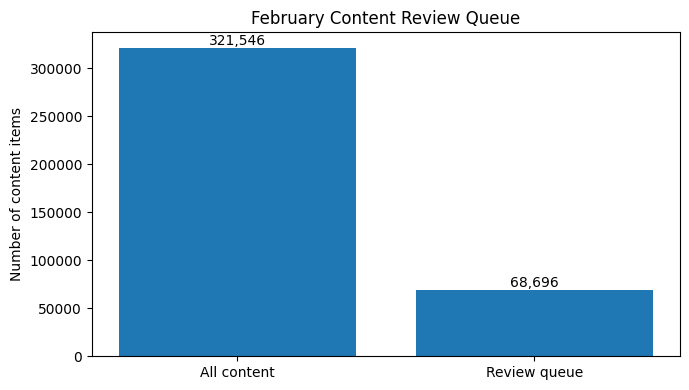

Figure exported:
work/figures/w07_action_queue_summary.png

Metrics receipt exported:
work/outputs/w07_action_playbook_metrics.json

EXPORT SUMMARY
--------------
Queue: work/outputs/w07_ranked_action_queue.csv
Figure: work/figures/w07_action_queue_summary.png
Metrics JSON: work/outputs/w07_action_playbook_metrics.json


In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# SECTION 5 — EXPORTS FOR THE PAPER
# ============================================================

import os
import json
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create required directories
# ------------------------------------------------------------

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)


# ------------------------------------------------------------
# 2. Export ranked action queue
# ------------------------------------------------------------

queue_path = "work/outputs/w07_ranked_action_queue.csv"

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Ranked queue exported:")
print(queue_path)


# ------------------------------------------------------------
# 3. Create a reusable paper figure
# ------------------------------------------------------------

total_items = len(action_frame)
review_candidates = len(ranked_queue)
review_rate = review_candidates / total_items

figure_path = "work/figures/w07_action_queue_summary.png"

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    ["All content", "Review queue"],
    [total_items, review_candidates]
)

ax.set_title("February Content Review Queue")
ax.set_ylabel("Number of content items")

for i, value in enumerate(
    [total_items, review_candidates]
):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Figure exported:")
print(figure_path)


# ------------------------------------------------------------
# 4. Export metrics receipt
# ------------------------------------------------------------

metrics = {
    "queue": {
        "total_content_items": int(total_items),
        "review_candidates": int(review_candidates),
        "review_candidate_rate": float(review_rate),
        "reason_code": "visible_low_ctr",
        "action_label": "REVIEW_CTR"
    },

    "validated_model": {
        "evaluation": "client_grouped",
        "accuracy": 0.7837,
        "precision": 0.8896,
        "recall": 0.4758,
        "f1": 0.6200,
        "client_overlap": 0
    },

    "comparison": {
        "random_split_accuracy": 0.8179,
        "grouped_split_accuracy": 0.7837,
        "random_split_f1": 0.6280,
        "grouped_split_f1": 0.6200,
        "random_split_client_overlap": 53,
        "grouped_split_client_overlap": 0
    },

    "leakage_audit": {
        "feature_set_matches": True,
        "target_in_features": False,
        "future_outcome_matches": [],
        "label_derived_matches": [],
        "product_availability_decision_matches": [],
        "leakage_check_passed": True
    }
}

metrics_path = (
    "work/outputs/"
    "w07_action_playbook_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(
        metrics,
        f,
        indent=2
    )

print("\nMetrics receipt exported:")
print(metrics_path)


# ------------------------------------------------------------
# 5. Final export summary
# ------------------------------------------------------------

print("\nEXPORT SUMMARY")
print("--------------")
print("Queue:", queue_path)
print("Figure:", figure_path)
print("Metrics JSON:", metrics_path)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.